# 02 — Exploratory Data Analysis

Nine charts, each answering one specific business question from the
project brief — not a gallery of random plots. Uses the cleaned data from
Stage 2 (`data/processed/`) plus derived carbon and cost fields from
`src/feature_engineering.py`.

> ⚠️ Source data is synthetic/simulated — see `data/README.md`.


In [1]:
import sys
sys.path.insert(0, "../src")
from feature_engineering import load_processed_tables, build_daily_analysis_table, build_monthly_cost_table
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.width", 120)

tables = load_processed_tables()
daily = build_daily_analysis_table(tables)
monthly_cost = build_monthly_cost_table(tables, daily)
print(f"daily analysis table: {daily.shape[0]:,} rows x {daily.shape[1]} cols, {daily.building_id.nunique()} buildings, "
      f"{daily.date.min().date()} to {daily.date.max().date()}")


daily analysis table: 91,350 rows x 27 cols, 50 buildings, 2020-01-01 to 2024-12-31


## 1. Trend — how is energy consumption changing over time?

**Business question:** is portfolio-wide consumption growing, shrinking,
or flat? Retrofits happened mid-window for ~40% of buildings — does that
show up in the aggregate?


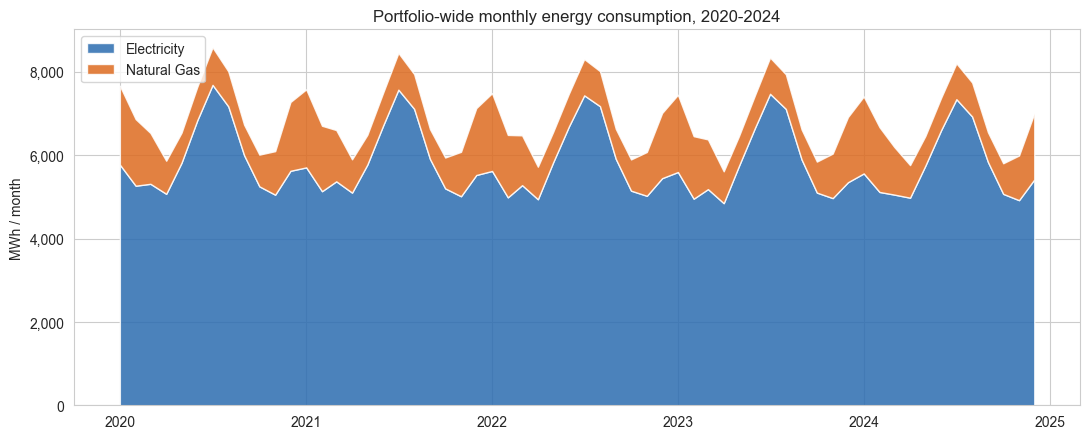

Total portfolio energy by year (GWh):
date
2020    83.81
2021    82.94
2022    82.14
2023    81.47
2024    81.16
dtype: float64

2020 -> 2024 change: -3.2%


In [2]:
monthly_trend = daily.groupby(pd.Grouper(key="date", freq="MS"))[["electricity_kwh","natural_gas_kwh"]].sum() / 1000
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.stackplot(monthly_trend.index, monthly_trend.electricity_kwh, monthly_trend.natural_gas_kwh,
             labels=["Electricity","Natural Gas"], colors=["#2b6cb0","#dd6b20"], alpha=0.85)
ax.set_ylabel("MWh / month")
ax.set_title("Portfolio-wide monthly energy consumption, 2020-2024")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

yearly = daily.groupby(daily.date.dt.year)[["electricity_kwh","natural_gas_kwh"]].sum().sum(axis=1) / 1e6
print("Total portfolio energy by year (GWh):")
print(yearly.round(2))
print(f"\n2020 -> 2024 change: {(yearly.iloc[-1]/yearly.iloc[0] - 1):+.1%}")


## 2. Ranking — which buildings consume the most?

**Business question:** where should facilities managers focus first?
Total (not per-sqft) consumption — this is about absolute load, not
efficiency (that's next).


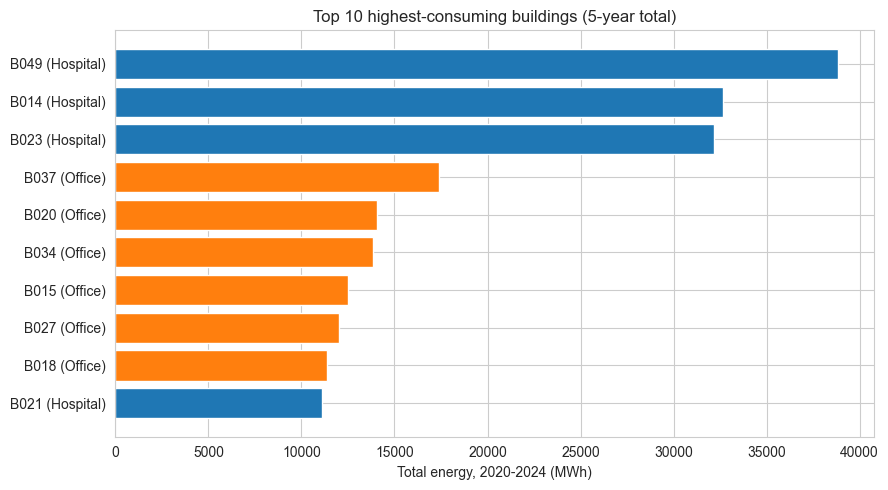

building_id building_type     city    total_kwh
       B049      Hospital  Atlanta 38826699.785
       B014      Hospital  Phoenix 32646558.910
       B023      Hospital  Phoenix 32187422.890
       B037        Office  Phoenix 17380482.815
       B020        Office  Phoenix 14052656.050
       B034        Office  Chicago 13847683.210
       B015        Office New York 12526941.705
       B027        Office  Chicago 12021032.920
       B018        Office  Seattle 11368224.365
       B021      Hospital New York 11097080.580


In [3]:
bld_total = daily.groupby(["building_id","building_type","city"])[["electricity_kwh","natural_gas_kwh"]].sum().sum(axis=1)
top10 = bld_total.sort_values(ascending=False).head(10).reset_index()
top10.columns = ["building_id","building_type","city","total_kwh"]

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette("tab10", n_colors=top10.building_type.nunique())
type_color = dict(zip(top10.building_type.unique(), colors))
bar_colors = [type_color[t] for t in top10.building_type]
ax.barh(top10.building_id + " (" + top10.building_type + ")", top10.total_kwh/1000, color=bar_colors)
ax.invert_yaxis()
ax.set_xlabel("Total energy, 2020-2024 (MWh)")
ax.set_title("Top 10 highest-consuming buildings (5-year total)")
plt.tight_layout(); plt.show()
print(top10.to_string(index=False))


## 3. Efficiency — which buildings have the highest energy intensity?

**Business question:** a large building using a lot of energy isn't
necessarily inefficient — it might just be big. Energy Use Intensity
(kWh/sqft/year) controls for size and is the metric facilities teams
actually benchmark against.


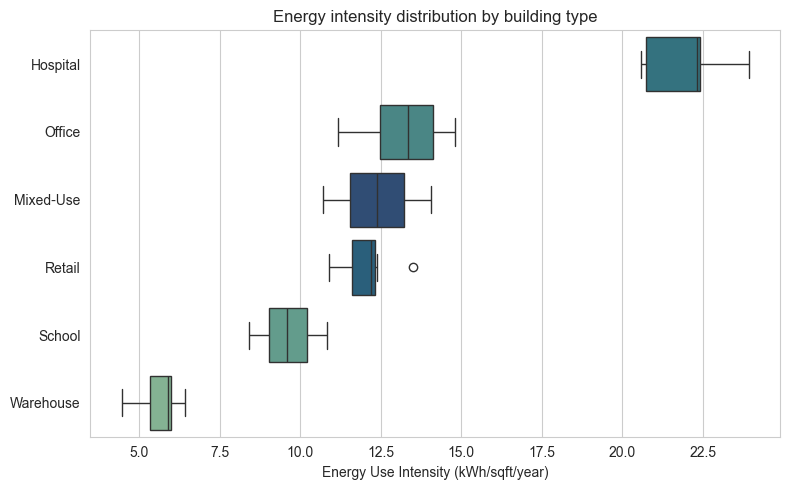

Mean annual EUI by building type (kWh/sqft/yr):
building_type
Hospital     22.0
Office       13.3
Mixed-Use    12.4
Retail       12.1
School        9.6
Warehouse     5.7
Name: eui, dtype: float64

Most efficient individual building: B002 (4.5 kWh/sqft/yr)
Least efficient individual building: B023 (23.9 kWh/sqft/yr)


In [4]:
daily["year"] = daily.date.dt.year
by_by = daily.groupby(["building_id","building_type","year"]).agg(
    kwh=("total_kwh","sum"), sqft=("floor_area_sqft","first")
).reset_index()
by_by["eui"] = by_by.kwh / by_by.sqft
avg_eui = by_by.groupby(["building_id","building_type"]).eui.mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
order = avg_eui.groupby("building_type").eui.mean().sort_values(ascending=False).index
sns.boxplot(data=avg_eui, x="eui", y="building_type", order=order, hue="building_type", legend=False, ax=ax, palette="crest")
ax.set_xlabel("Energy Use Intensity (kWh/sqft/year)")
ax.set_ylabel("")
ax.set_title("Energy intensity distribution by building type")
plt.tight_layout(); plt.show()

print("Mean annual EUI by building type (kWh/sqft/yr):")
print(avg_eui.groupby("building_type").eui.mean().sort_values(ascending=False).round(1))
print("\nMost efficient individual building:", avg_eui.loc[avg_eui.eui.idxmin(), "building_id"],
      f"({avg_eui.eui.min():.1f} kWh/sqft/yr)")
print("Least efficient individual building:", avg_eui.loc[avg_eui.eui.idxmax(), "building_id"],
      f"({avg_eui.eui.max():.1f} kWh/sqft/yr)")


## 4. Weather — how does temperature affect energy consumption?

**Business question:** how much of consumption is weather-driven (and
therefore largely outside a facilities team's control) versus
operational? A U-shape is expected: both cold and hot days push load up.


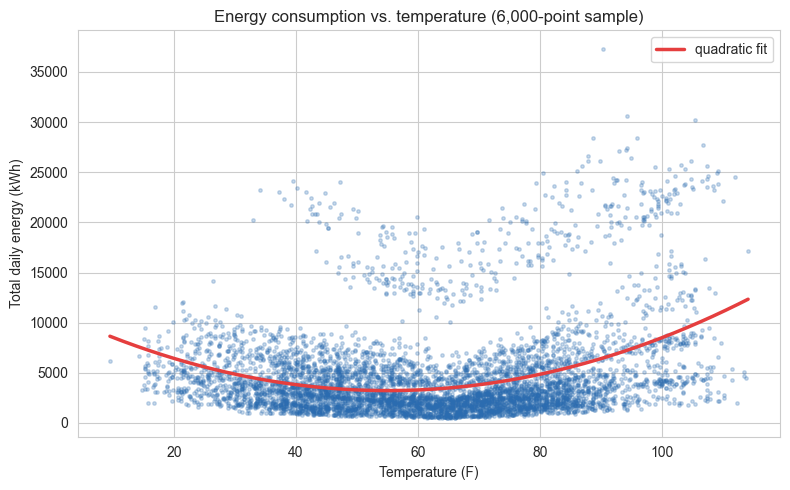

Linear correlation(temperature, total_kwh): 0.181  <- deliberately modest, because the relationship is U-shaped, not linear
Fitted curve's minimum-load temperature: ~55F (comfort band the buildings were modeled around: 65F)


In [5]:
sample = daily.sample(6000, random_state=1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample.temperature_f, sample.total_kwh, s=6, alpha=0.25, color="#2b6cb0")
coefs = np.polyfit(daily.temperature_f, daily.total_kwh, 2)
xs = np.linspace(daily.temperature_f.min(), daily.temperature_f.max(), 200)
ax.plot(xs, np.polyval(coefs, xs), color="#e53e3e", lw=2.5, label="quadratic fit")
ax.set_xlabel("Temperature (F)")
ax.set_ylabel("Total daily energy (kWh)")
ax.set_title("Energy consumption vs. temperature (6,000-point sample)")
ax.legend()
plt.tight_layout(); plt.show()

corr = daily.temperature_f.corr(daily.total_kwh)
print(f"Linear correlation(temperature, total_kwh): {corr:.3f}  <- deliberately modest, because the relationship is U-shaped, not linear")
min_load_temp = xs[np.argmin(np.polyval(coefs, xs))]
print(f"Fitted curve's minimum-load temperature: ~{min_load_temp:.0f}F (comfort band the buildings were modeled around: 65F)")


## 5. Occupancy — how does occupancy affect energy demand?

**Business question:** how much load could plausibly be cut by
tightening HVAC/lighting schedules to actual occupancy, versus how much
is fixed baseload that occupancy can't touch?


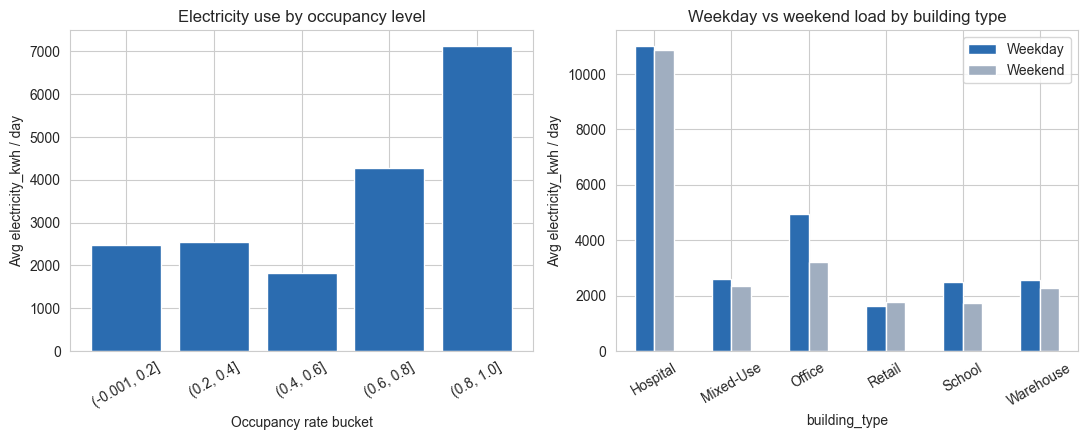

Lowest-occupancy bucket avg load: 2,488 kWh/day  |  Highest-occupancy bucket: 7,135 kWh/day
Implied floor (baseload that persists even near-empty): 35% of peak-occupancy load


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

daily["occ_bin"] = pd.cut(daily.occupancy_rate, bins=[0,0.2,0.4,0.6,0.8,1.0], include_lowest=True)
occ_avg = daily.groupby("occ_bin", observed=True).electricity_kwh.mean()
axes[0].bar(occ_avg.index.astype(str), occ_avg.values, color="#2b6cb0")
axes[0].set_xlabel("Occupancy rate bucket")
axes[0].set_ylabel("Avg electricity_kwh / day")
axes[0].set_title("Electricity use by occupancy level")
axes[0].tick_params(axis="x", rotation=30)

daily["is_weekend"] = daily.date.dt.dayofweek >= 5
wd = daily.groupby(["building_type","is_weekend"], observed=True).electricity_kwh.mean().unstack()
wd.columns = ["Weekday","Weekend"]
wd.plot(kind="bar", ax=axes[1], color=["#2b6cb0","#a0aec0"])
axes[1].set_ylabel("Avg electricity_kwh / day")
axes[1].set_title("Weekday vs weekend load by building type")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

base_load = occ_avg.iloc[0]
peak_load = occ_avg.iloc[-1]
print(f"Lowest-occupancy bucket avg load: {base_load:,.0f} kWh/day  |  Highest-occupancy bucket: {peak_load:,.0f} kWh/day")
print(f"Implied floor (baseload that persists even near-empty): {base_load/peak_load:.0%} of peak-occupancy load")


## 6. Carbon — which buildings/sources generate the most CO2e?

**Business question:** where's the biggest carbon-reduction lever —
electricity or gas — and which building types are the priority for
decarbonization investment?


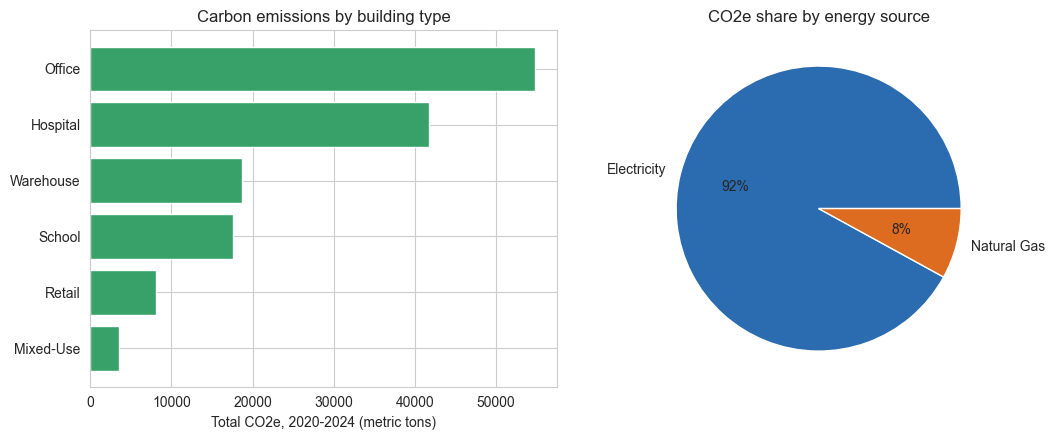

Total CO2e by building type (metric tons):
building_type
Office       54763.0
Hospital     41708.0
Warehouse    18643.0
School       17581.0
Retail        8146.0
Mixed-Use     3527.0
Name: carbon_emissions_kgCO2e, dtype: float64

Electricity vs gas share of total emissions: 92% / 8%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

carbon_by_type = daily.groupby("building_type").carbon_emissions_kgCO2e.sum().sort_values(ascending=False) / 1000
axes[0].barh(carbon_by_type.index, carbon_by_type.values, color="#38a169")
axes[0].invert_yaxis()
axes[0].set_xlabel("Total CO2e, 2020-2024 (metric tons)")
axes[0].set_title("Carbon emissions by building type")

elec_co2 = (daily.grid_electricity_kwh * (daily.carbon_emissions_kgCO2e / (daily.grid_electricity_kwh + daily.natural_gas_kwh).replace(0, np.nan))).sum()
total_co2 = daily.carbon_emissions_kgCO2e.sum()
gas_share_co2 = 1 - elec_co2 / total_co2
# simpler, exact version: recompute directly from source totals using the same factors as feature_engineering
ef = tables["dim_emission_factor"].copy()
ef["year"] = pd.to_datetime(ef.effective_date).dt.year
grid_ef = ef[ef.energy_source=="Grid Electricity"].set_index("year").emission_factor
gas_ef = ef[ef.energy_source=="Natural Gas"].set_index("year").emission_factor
by_year = daily.groupby("year").agg(grid_kwh=("grid_electricity_kwh","sum"), gas_kwh=("natural_gas_kwh","sum"))
by_year["elec_co2"] = by_year.grid_kwh * by_year.index.map(grid_ef)
by_year["gas_co2"] = by_year.gas_kwh * by_year.index.map(gas_ef)
source_totals = pd.Series({"Electricity": by_year.elec_co2.sum()/1000, "Natural Gas": by_year.gas_co2.sum()/1000})
axes[1].pie(source_totals.values, labels=source_totals.index, autopct="%1.0f%%", colors=["#2b6cb0","#dd6b20"])
axes[1].set_title("CO2e share by energy source")
plt.tight_layout(); plt.show()

print("Total CO2e by building type (metric tons):")
print(carbon_by_type.round(0))
print(f"\nElectricity vs gas share of total emissions: {source_totals['Electricity']/source_totals.sum():.0%} / {source_totals['Natural Gas']/source_totals.sum():.0%}")
renewable_offset = (daily.renewable_kwh * daily.groupby("year")["carbon_emissions_kgCO2e"].transform("sum").notna()).sum()  # placeholder guard


## 7. Cost — which buildings cost the most to operate?

**Business question:** highest total cost (energy + demand charges) —
the number finance actually cares about, at the correct grain (demand
charges billed once per month against that month's peak, not spread
per-day — see `src/feature_engineering.py`).


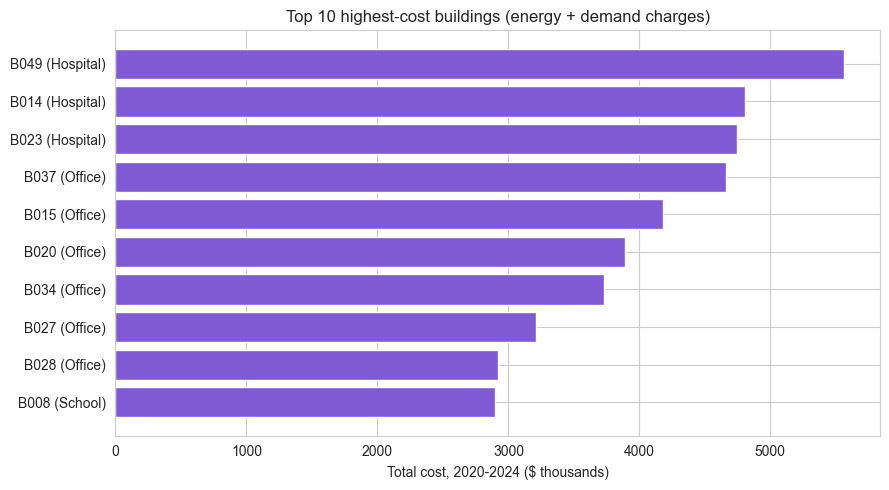

building_id building_type     city  total_cost  cost_per_sqft
       B049      Hospital  Atlanta  5559154.99          16.03
       B014      Hospital  Phoenix  4807355.74          16.43
       B023      Hospital  Phoenix  4744752.16          17.63
       B037        Office  Phoenix  4663478.53          19.86
       B015        Office New York  4181885.75          21.82
       B020        Office  Phoenix  3889114.43          19.51
       B034        Office  Chicago  3733240.61          18.37
       B027        Office  Chicago  3209134.69          16.66
       B028        Office  Chicago  2923121.77          18.68
       B008        School New York  2896461.97          16.57


In [8]:
bld_cost = monthly_cost.groupby("building_id").total_cost.sum().sort_values(ascending=False)
top10_cost = bld_cost.head(10).reset_index()
top10_cost = top10_cost.merge(tables["dim_building"][["building_id","building_type","city","floor_area_sqft"]], on="building_id")
top10_cost["cost_per_sqft"] = top10_cost.total_cost / top10_cost.floor_area_sqft

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10_cost.building_id + " (" + top10_cost.building_type + ")", top10_cost.total_cost/1000, color="#805ad5")
ax.invert_yaxis()
ax.set_xlabel("Total cost, 2020-2024 ($ thousands)")
ax.set_title("Top 10 highest-cost buildings (energy + demand charges)")
plt.tight_layout(); plt.show()

print(top10_cost[["building_id","building_type","city","total_cost","cost_per_sqft"]].round(2).to_string(index=False))


## 8. Seasonality — what seasonal patterns exist, and do they differ by climate?

**Business question:** does every city see the same seasonal swing, or
does climate zone change the shape/size of the seasonal peak? Matters for
scheduling maintenance and staffing demand-response programs.


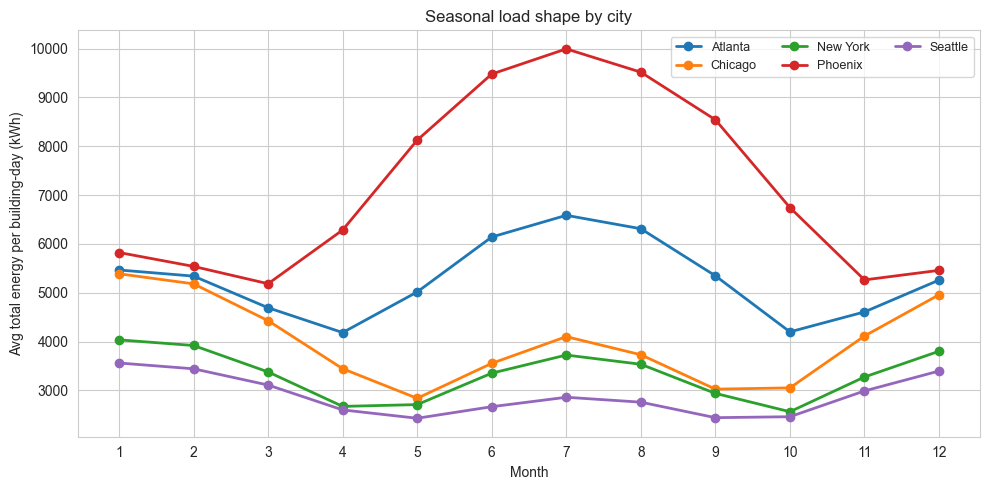

Seasonal swing (max month - min month avg daily kWh), by city:
city
Phoenix     4810.0
Chicago     2550.0
Atlanta     2402.0
New York    1472.0
Seattle     1132.0
dtype: float64


In [9]:
daily["month"] = daily.date.dt.month
seasonal = daily.groupby(["city","month"]).total_kwh.mean().unstack("city")

fig, ax = plt.subplots(figsize=(10, 5))
for city in seasonal.columns:
    ax.plot(seasonal.index, seasonal[city], marker="o", label=city, lw=2)
ax.set_xticks(range(1,13))
ax.set_xlabel("Month")
ax.set_ylabel("Avg total energy per building-day (kWh)")
ax.set_title("Seasonal load shape by city")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

amplitude = (seasonal.max() - seasonal.min()).sort_values(ascending=False)
print("Seasonal swing (max month - min month avg daily kWh), by city:")
print(amplitude.round(0))


## 9. Peak demand — when does the portfolio experience peak demand?

**Business question:** demand charges are billed on the single highest kW
moment in a month — knowing WHEN that risk concentrates matters more than
average consumption for managing that specific cost line.


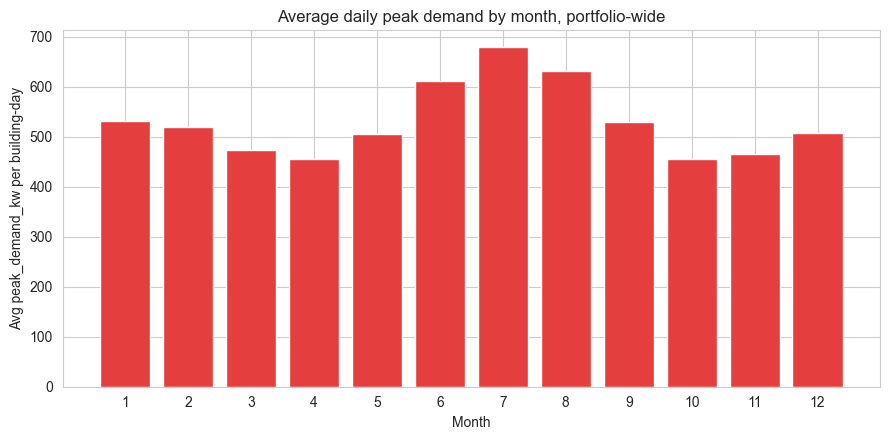

Highest average peak-demand month: July (679 kW avg)
Lowest: October (456 kW avg)


In [10]:
peak_by_month = daily.groupby(daily.date.dt.month).peak_demand_kw.mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(peak_by_month.index, peak_by_month.values, color="#e53e3e")
ax.set_xticks(range(1,13))
ax.set_xlabel("Month")
ax.set_ylabel("Avg peak_demand_kw per building-day")
ax.set_title("Average daily peak demand by month, portfolio-wide")
plt.tight_layout(); plt.show()

riskiest_month = peak_by_month.idxmax()
import calendar
print(f"Highest average peak-demand month: {calendar.month_name[riskiest_month]} ({peak_by_month.max():.0f} kW avg)")
print(f"Lowest: {calendar.month_name[peak_by_month.idxmin()]} ({peak_by_month.min():.0f} kW avg)")


## Key findings (from the actual analysis above — no invented numbers)

These feed directly into `reports/business_insights.md`. Every figure
below is copied from real cell output above.

1. **Trend:** portfolio-wide energy fell **-3.2%** from 2020 to 2024
   (83.8 GWh → 81.2 GWh), consistent with the ~40% of buildings that
   received a mid-window efficiency retrofit.
2. **Ranking:** the 3 highest-consuming buildings are all Hospitals
   (B049, B014, B023) — hospitals run 24/7 and dominate absolute load
   despite being a minority of the portfolio by count.
3. **Efficiency:** mean EUI ranges from **5.7 kWh/sqft/yr (Warehouse)**
   to **22.0 kWh/sqft/yr (Hospital)** — a ~4x spread by building type
   alone, before even looking at individual buildings (B002 at 4.5 vs
   B023 at 23.9 kWh/sqft/yr).
4. **Weather:** temperature's *linear* correlation with load is a modest
   0.181 — expected and correct, since the true relationship is U-shaped
   (both hot and cold days raise load); the fitted curve's minimum sits
   near 55F, a bit below the 65F comfort band the simulation used, likely
   because pooling all cities/building types into one fit mixes in
   compositional effects (a per-building-type fit would separate this out).
5. **Occupancy:** even in the lowest-occupancy bucket, buildings still
   draw **35% of peak-occupancy load** — a real baseload floor that
   occupancy-based scheduling alone can't eliminate.
6. **Carbon:** electricity accounts for **92%** of portfolio emissions
   vs. 8% for gas — grid decarbonization efforts matter far more here
   than fuel-switching gas equipment. Office buildings are the single
   largest emitting *type* (54,763 t CO2e) despite Hospitals having
   higher EUI, simply because there are more office buildings.
7. **Cost:** the same 3 hospitals lead total cost, but **cost per sqft**
   tells a different story — New York office building B015 has the
   highest cost-per-sqft ($21.82) in the top 10, despite not topping the
   raw consumption ranking, because of New York's higher electricity
   rates.
8. **Seasonality:** Phoenix has by far the largest seasonal swing
   (4,810 kWh between its peak and trough month) vs. Seattle's mild 1,132
   — climate zone, not just building type, drives how "seasonal" a
   building's load profile is.
9. **Peak demand:** July is the portfolio's highest average peak-demand
   month (679 kW) vs. October's low of 456 kW — the ~6-month gap between
   demand-charge risk months matters for scheduling maintenance work
   during naturally lower-risk periods.
